### Where is Waldo Project Overview

The “Where’s Waldo?” picture game is a task where the goal is to locate the titular character "Waldo" within a densely populated image filled with distracting patterns, colors, and similar-looking characters. A CNN's approach to this problem is by learning hierarchical visual features, starting from simple edges and textures in early layers to more complex shapes and patterns in deeper layers. Through training on labeled examples of close ups of both "waldo" and "not waldo" images, the network learns to distinguish Waldo’s unique attributes, such as his red-and-white striped shirt and hat, from the "not waldo" surrandings. This CNN should be able to find Waldo in larger images based on snapshots of Waldo and his surrandings.  

Data pulled from Aleksey Bilogur's "Where's Waldo" on Kaggle:
https://www.kaggle.com/datasets/residentmario/wheres-waldo/data

### Dataset Description

**Source:** "Where's Waldo" dataset from Kaggle (Aleksey Bilogur)

**Dataset Purpose:** A binary image classification task to detect whether a given image patch contains Waldo or not.

**Classes:**
- **Waldo (Class 1):** Image crops containing Waldo's distinctive red-and-white striped shirt and hat
- **Not Waldo (Class 0):** Image crops of background scenery, other characters, or distracting patterns

**Dataset Split:**
- **Training Set:** 5,449 labeled images total in train folder
  - Waldo images: 96 samples
  - Not-Waldo images: 5,353 samples
  - Note: Highly imbalanced dataset (1.8% positive class)
- **Test Set:** 19 unlabeled images (for evaluating generalization)

**Input Features:**
- Raw pixel values from RGB color images
- Original images have varying dimensions:
  - Waldo patches: 64×64 pixels
  - Not-Waldo patches: typically 256×256 pixels
- All images resized to uniform dimensions of **224×224×3** for model training, where:
  - 224 = image height (pixels)
  - 224 = image width (pixels)  
  - 3 = RGB color channels

**Outcome Variable:**
- **Binary label:**
  - 1 = Waldo present
  - 0 = Waldo not present

**Data Format:**
- Stored in directory structure: `data/train/{waldo, nowaldo}/` and `data/test/`
- Image format: JPEG files
- Pixel values normalized to [0, 1] by dividing by 255

In [ ]:
#Importing needed software for a neural network for image id
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from helpers import plot_sample_images, plot_predictions


import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array, save_img
tf.random.set_seed(42)
np.random.seed(42)

# Report available accelerators
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU acceleration: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — using CPU")

from tensorflow import keras
from keras import Sequential
from keras.layers import RandomFlip, RandomRotation, RandomZoom
from keras.layers import (
    Dense, Flatten, Dropout, Conv2D, MaxPooling2D, LSTM, Input
)
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Define image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

#resize all images to 128x128
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)

#rescale pixel values to [0, 1]
from keras.layers import Rescaling

rescale = Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Input(shape=(224, 224, 3))

#confirm rescaling worked
for images, labels in train_ds.take(1):
    print("Pixel value range:", (tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy()))

#start making cnn here no need to further split data


No GPU detected — using CPU
Found 5449 files belonging to 2 classes.
Image batch shape: (32, 224, 224, 3)
Pixel value range: (0.0, 1.0)


In [79]:
#1. Define Model CNN + augmentation to improve performance
data_augmentation = keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
])

waldo_cnn = Sequential([
    Input(shape=(224, 224, 3)),
    data_augmentation,

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

#2. Compile the model
waldo_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

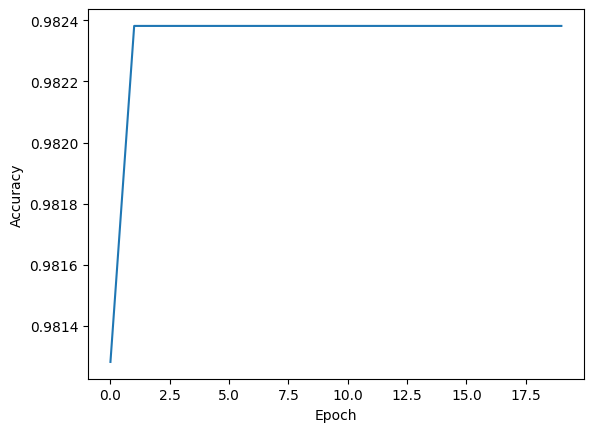

In [80]:
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

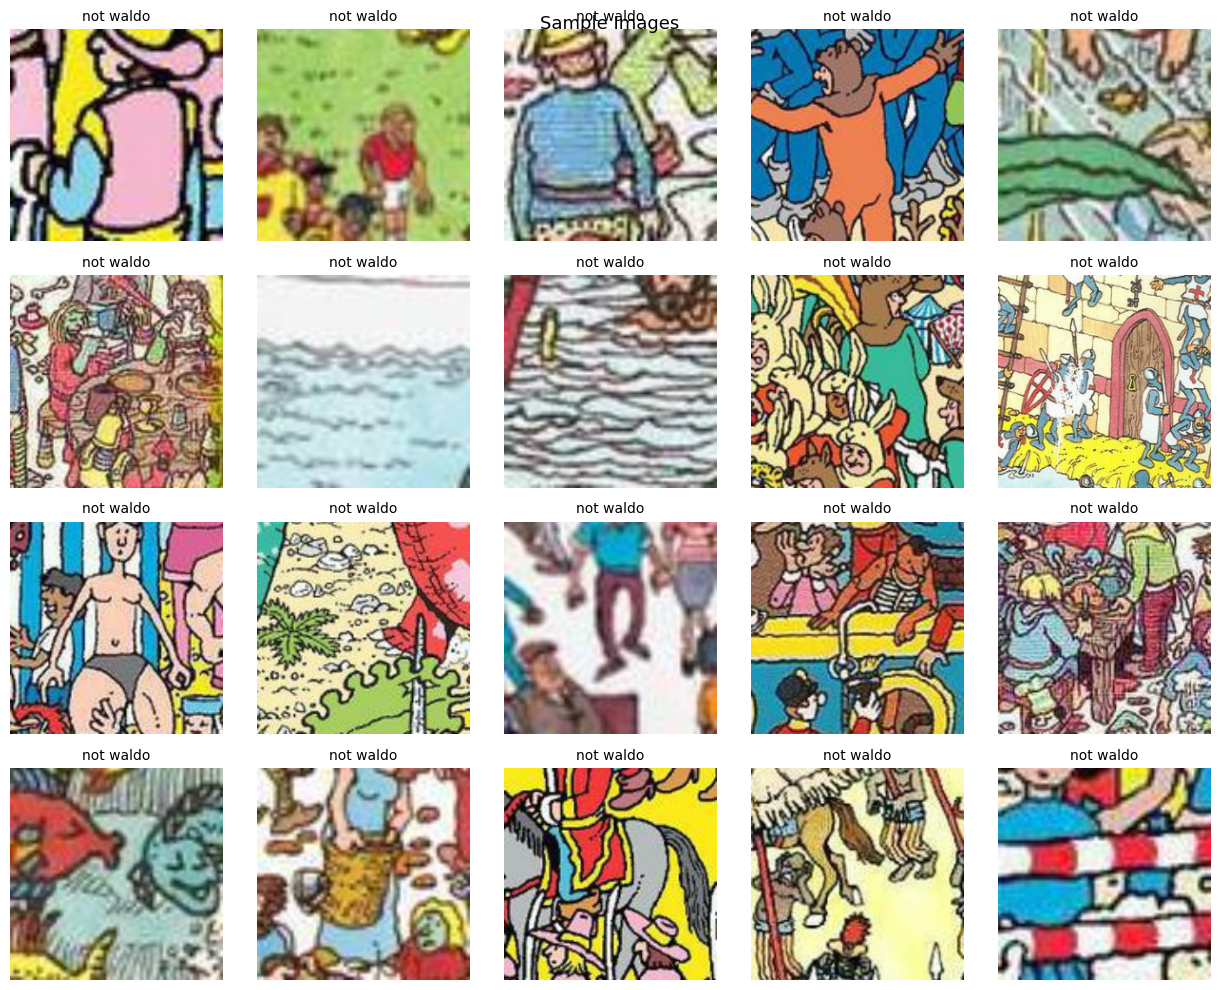

In [81]:
# Test plot_sample_images on the train set
imgs, lbls = next(iter(train_ds))
plot_sample_images(
    imgs.numpy(),
    tf.keras.utils.to_categorical(lbls, 2),
    class_names={0: "not waldo", 1: "waldo"},
    n=20, cols=5
)


In [68]:
#3. Fit the model
history = waldo_cnn.fit(train_ds, epochs=20)

Epoch 1/20
171/171 [==============================] - 121s 698ms/step - loss: 0.1472 - accuracy: 0.9813
Epoch 2/20
171/171 [==============================] - 123s 719ms/step - loss: 0.1048 - accuracy: 0.9824
Epoch 3/20
171/171 [==============================] - 111s 650ms/step - loss: 0.0997 - accuracy: 0.9824
Epoch 4/20
171/171 [==============================] - 112s 654ms/step - loss: 0.0957 - accuracy: 0.9824
Epoch 5/20
171/171 [==============================] - 127s 743ms/step - loss: 0.0990 - accuracy: 0.9824
Epoch 6/20
171/171 [==============================] - 118s 690ms/step - loss: 0.0918 - accuracy: 0.9824
Epoch 7/20
171/171 [==============================] - 121s 705ms/step - loss: 0.1048 - accuracy: 0.9824
Epoch 8/20
171/171 [==============================] - 117s 683ms/step - loss: 0.0942 - accuracy: 0.9824
Epoch 9/20
171/171 [==============================] - 112s 652ms/step - loss: 0.0959 - accuracy: 0.9824
Epoch 10/20
171/171 [==============================] - 112s 653m

In [82]:
# Check training accuracy
print("Final training accuracy:", history.history['accuracy'][-1])

Final training accuracy: 0.98238205909729


In [83]:
# 4. Predict
predictions = waldo_cnn.predict(train_ds)
print(predictions[:5])  # Print the first 5 predictions

171/171 [==============================] - 26s 149ms/step
[[0.51490885]
 [0.52304417]
 [0.5294802 ]
 [0.52555984]
 [0.5329351 ]]


In [84]:
# import test folder and prepare images
# the test directory has unlabeled images so we load with label_mode=None

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    batch_size=BATCH_SIZE,
    label_mode=None,
    shuffle=False
)

test_ds = test_ds.map(lambda x: tf.image.resize(x, [224, 224]))
test_ds = test_ds.map(lambda x: rescale(x))

# Check the shape of the loaded images
for images in test_ds.take(1):
    print("Test image batch shape:", images.shape)
    break

# now check to see if the model can predict on test data using the batched dataset
test_predictions = waldo_cnn.predict(test_ds)
print("Test predictions shape:", test_predictions.shape)


#rescale
test_ds = test_ds.map(lambda x: x / 255.0)

Found 19 files belonging to 1 classes.
Test image batch shape: (19, 224, 224, 3)
1/1 [==============================] - 0s 240ms/step
Test predictions shape: (19, 1)


1/1 [==============================] - 0s 117ms/step


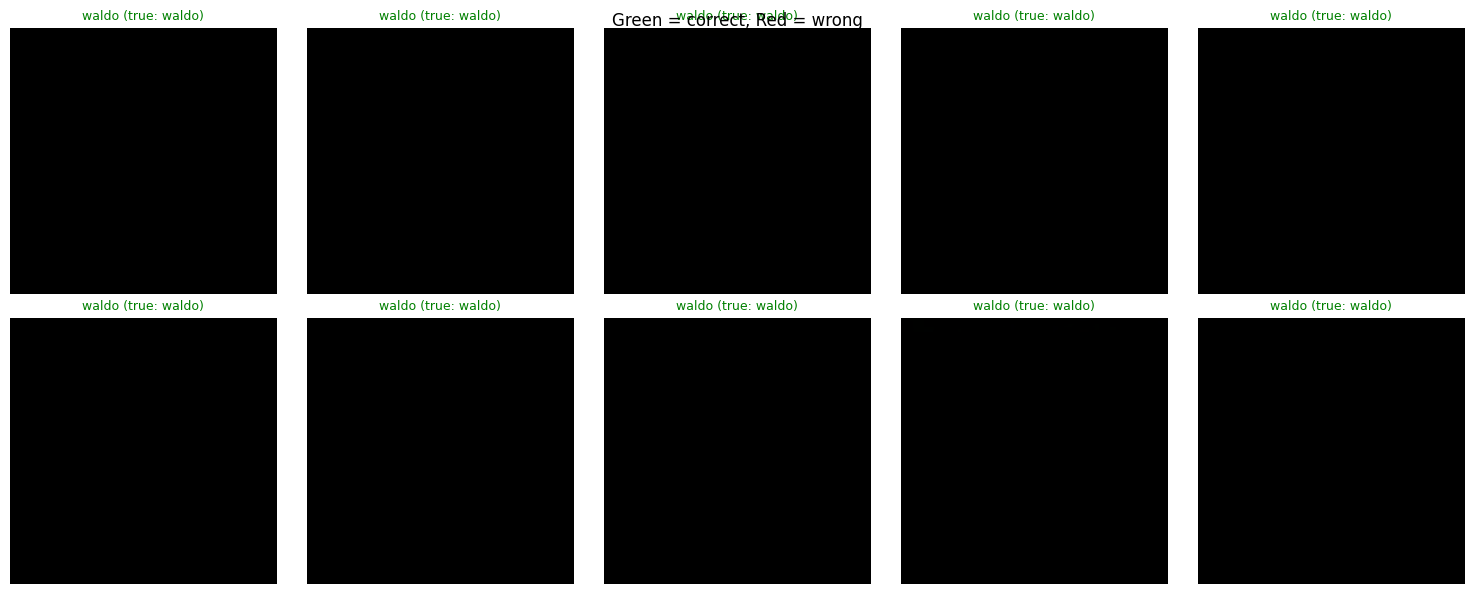

1/1 [==============================] - 0s 113ms/step
Image 0: prob_waldo = 0.500
Image 1: prob_waldo = 0.500
Image 2: prob_waldo = 0.500
Image 3: prob_waldo = 0.500
Image 4: prob_waldo = 0.500


In [92]:
imgs = next(iter(test_ds))
preds = waldo_cnn.predict(imgs)
y_pred = (preds > 0.5).astype(int).squeeze()

plot_predictions(
    imgs.numpy(),
    y_pred,
    y_pred,
    class_names={0: "not waldo", 1: "waldo"},
    n=10,
    cols=5
)

#print predicted probabilities for first 5 test images
imgs = next(iter(test_ds))
preds = waldo_cnn.predict(imgs).squeeze()

for i in range(5):
    print(f"Image {i}: prob_waldo = {preds[i]:.3f}")

In [91]:
# Debug: Check the range of pixel values in the test images
imgs = next(iter(test_ds))
print("Min pixel value:", imgs.numpy().min())
print("Max pixel value:", imgs.numpy().max())
print("Mean pixel value:", imgs.numpy().mean())
print("Image shape:", imgs.shape)

Min pixel value: 0.0
Max pixel value: 0.003921569
Mean pixel value: 0.0022298016
Image shape: (19, 224, 224, 3)
